In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
# Set random seed for reproducibility
rng = np.random.default_rng(42)

# Model parameters
LAMBDA_DEMAND = 30        # mean weekly demand (Poisson)
CO = 50.0                 # fixed ordering cost per order
CV = 25.0                 # variable cost per dose
H = 0.5                   # holding cost per dose per week
W = 25.0                  # wastage cost per expired dose
P = 40.0                  # shortage penalty cost per unit unmet demand
SHELF_LIFE = 8            # shelf life in weeks
CAPACITY = 300            # maximum storage capacity (doses)
N_WEEKS = 52              # planning horizon per replication
N_REPS = 200              # number of simulation replications per policy

# Simulate a single (s, S) policy
def simulate_policy(s, S, lambda_d=LAMBDA_DEMAND):
    total_costs = []
    total_demand = 0
    total_served = 0
    total_expired = []
    for rep in range(N_REPS):
        # inventory[i] = units with age i (0=newest, last=oldest)
        inventory = np.zeros(SHELF_LIFE, dtype=int)
        rep_cost = 0
        rep_expired = 0
        for t in range(N_WEEKS):
            # current inventory level
            on_hand = inventory.sum()
            # ordering decision (s, S policy)
            order_qty = S - on_hand if on_hand < s else 0
            order_qty = min(order_qty, CAPACITY - on_hand)
            if order_qty > 0:
                rep_cost += CO
            rep_cost += CV * order_qty
            # demand realization
            demand = rng.poisson(lambda_d)
            total_demand += demand
            served = 0
            remaining = demand
            # FEFO: serve oldest inventory first
            for i in reversed(range(SHELF_LIFE)):
                used = min(inventory[i], remaining)
                inventory[i] -= used
                served += used
                remaining -= used
            total_served += served
            # shortage penalty
            unmet = demand - served
            rep_cost += P * unmet
            # expiration (oldest stock expires)
            expired = inventory[-1]
            rep_expired += expired
            rep_cost += W * expired
            # age inventory by one week
            inventory[1:] = inventory[:-1]
            inventory[0] = 0
            # new order arrives as fresh stock
            inventory[0] += order_qty
            # holding cost
            rep_cost += H * inventory.sum()
        total_costs.append(rep_cost / N_WEEKS)
        total_expired.append(rep_expired / N_WEEKS)
    return {
        "s": s,
        "S": S,
        "avg_weekly_cost": np.mean(total_costs),
        "service_level": total_served / total_demand,
        "avg_expired_per_week": np.mean(total_expired)
    }

# Grid search over (s, S)
def grid_search(s_values, S_values, lambda_d=LAMBDA_DEMAND):
    results = []
    for s in s_values:
        for S in S_values:
            if S <= s:
                continue
            res = simulate_policy(s, S, lambda_d)
            results.append(res)
            print(f"s={s}, S={S}, cost={res['avg_weekly_cost']:.2f}, service={res['service_level']:.3f}")
    return pd.DataFrame(results)

# Search space for (s, S)
s_grid = np.arange(0, 201, 20)
S_grid = np.arange(80, 301, 20)

# Run grid search
results_df = grid_search(s_grid, S_grid)

# Best policy
best = results_df.loc[results_df['avg_weekly_cost'].idxmin()]

print("\nBest Policy:")
print(best)

print("\nTop 10 Policies:")
print(results_df.sort_values('avg_weekly_cost').head(10))

s=0, S=80, cost=1200.00, service=0.000
s=0, S=100, cost=1200.25, service=0.000
s=0, S=120, cost=1200.08, service=0.000
s=0, S=140, cost=1197.99, service=0.000
s=0, S=160, cost=1201.02, service=0.000
s=0, S=180, cost=1196.50, service=0.000
s=0, S=200, cost=1200.96, service=0.000
s=0, S=220, cost=1196.71, service=0.000
s=0, S=240, cost=1200.14, service=0.000
s=0, S=260, cost=1202.13, service=0.000
s=0, S=280, cost=1202.58, service=0.000
s=0, S=300, cost=1199.12, service=0.000
s=20, S=80, cost=920.12, service=0.736
s=20, S=100, cost=912.55, service=0.777
s=20, S=120, cost=903.84, service=0.805
s=20, S=140, cost=904.66, service=0.829
s=20, S=160, cost=904.44, service=0.848
s=20, S=180, cost=896.63, service=0.863
s=20, S=200, cost=909.44, service=0.873
s=20, S=220, cost=934.02, service=0.877
s=20, S=240, cost=939.29, service=0.883
s=20, S=260, cost=1015.58, service=0.884
s=20, S=280, cost=1127.54, service=0.885
s=20, S=300, cost=1242.89, service=0.885
s=40, S=80, cost=873.52, service=0.871


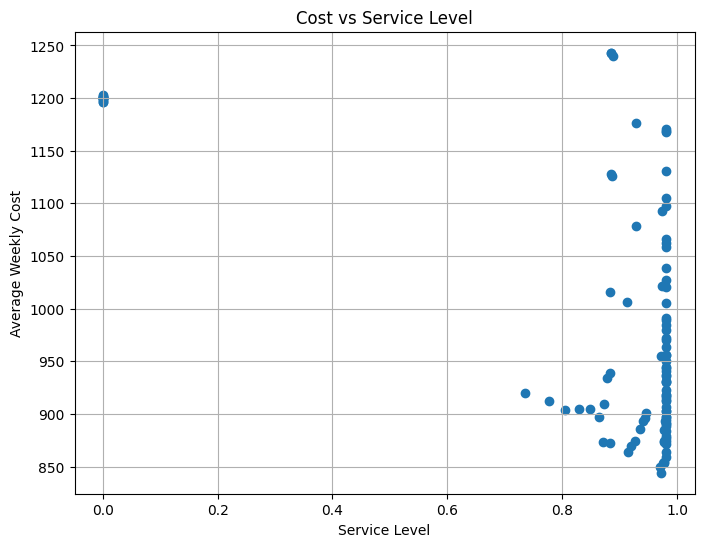

In [19]:
# Cost vs Service Level plot
plt.figure(figsize=(8,6))
plt.scatter(results_df['service_level'], results_df['avg_weekly_cost'])
plt.xlabel("Service Level")
plt.ylabel("Average Weekly Cost")
plt.title("Cost vs Service Level")
plt.grid()
plt.show()

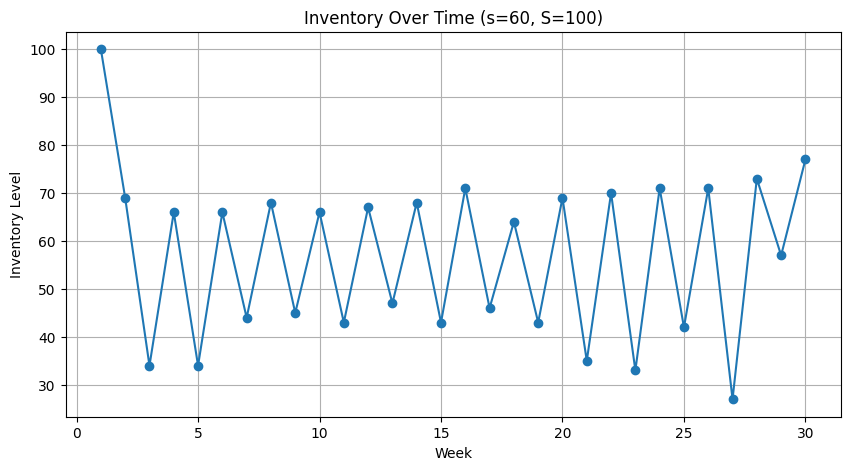

In [20]:
# Simulate inventory trajectory for best policy
def simulate_trajectory(s, S, weeks=30):
    inventory = np.zeros(SHELF_LIFE, dtype=int)
    levels = []
    for t in range(weeks):
        on_hand = inventory.sum()
        order_qty = S - on_hand if on_hand < s else 0
        order_qty = min(order_qty, CAPACITY - on_hand)
        # demand
        demand = rng.poisson(LAMBDA_DEMAND)
        # FEFO fulfillment
        remaining = demand
        for i in reversed(range(SHELF_LIFE)):
            used = min(inventory[i], remaining)
            inventory[i] -= used
            remaining -= used
        # expiration
        expired = inventory[-1]
        # aging
        inventory[1:] = inventory[:-1]
        inventory[0] = 0
        # new order arrives
        inventory[0] += order_qty
        levels.append(inventory.sum())
    return levels
    
trajectory = simulate_trajectory(int(best['s']), int(best['S']))

plt.figure(figsize=(10,5))
plt.plot(range(1,31), trajectory, marker='o')
plt.xlabel("Week")
plt.ylabel("Inventory Level")
plt.title(f"Inventory Over Time (s={int(best['s'])}, S={int(best['S'])})")
plt.grid()
plt.show()

In [ ]:
# Sensitivity Analysis 
lambdas = [25, 30, 35]
sensitivity_results = []

for lam in lambdas:
    df = grid_search(s_grid, S_grid, lambda_d=lam)
    best_row = df.loc[df['avg_weekly_cost'].idxmin()]
    sensitivity_results.append({
        "lambda": lam,
        "best_s": best_row["s"],
        "best_S": best_row["S"],
        "cost": best_row["avg_weekly_cost"],
        "service": best_row["service_level"]
    })
sens_df = pd.DataFrame(sensitivity_results)

print("\nSensitivity Analysis Results:")
print(sens_df)

s=0, S=80, cost=1001.60, service=0.000
s=0, S=100, cost=998.42, service=0.000
s=0, S=120, cost=999.52, service=0.000
s=0, S=140, cost=1001.13, service=0.000
s=0, S=160, cost=1002.71, service=0.000
s=0, S=180, cost=1001.87, service=0.000
s=0, S=200, cost=998.36, service=0.000
s=0, S=220, cost=997.92, service=0.000
s=0, S=240, cost=1000.88, service=0.000
s=0, S=260, cost=1001.12, service=0.000
s=0, S=280, cost=1001.23, service=0.000
s=0, S=300, cost=1000.20, service=0.000
s=20, S=80, cost=760.36, service=0.785
s=20, S=100, cost=748.89, service=0.825
s=20, S=120, cost=744.65, service=0.852
s=20, S=140, cost=757.04, service=0.866
s=20, S=160, cost=757.27, service=0.883
s=20, S=180, cost=756.93, service=0.891
s=20, S=200, cost=799.73, service=0.890
s=20, S=220, cost=864.23, service=0.885
s=20, S=240, cost=980.96, service=0.885
s=20, S=260, cost=1096.20, service=0.884
s=20, S=280, cost=1208.82, service=0.885
s=20, S=300, cost=1324.88, service=0.884
s=40, S=80, cost=709.88, service=0.943
s=40